In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter

np.random.seed(42)

In [2]:
import json

sessions = []
with open("sessions.jsonl") as f:
    for line in f:
        line = line.strip()
        if line:
            sessions.append(json.loads(line))

print(f"Всего сессий: {len(sessions)}")
print(f"Первая сессия: {sessions[0]}")

Всего сессий: 2565
Первая сессия: [380, 293, 262, 114, 123, 345, 335, 245, 272, 293, 233, 302, 247, 290, 260, 341, 293]


In [3]:
def train_test_split(
    sessions: list[list[int]],
) -> tuple[list[list[int]], list[int]]:
    train_sessions = [session[:-1] for session in sessions]
    test_targets = [session[-1] for session in sessions]
    return train_sessions, test_targets

In [4]:
def hit_at_k(
    recommendations: list[list[int]],
    true_items: list[int],
    k: int = 10,
) -> float:

    assert len(recommendations) == len(true_items), \
        "recommendations и true_items должны совпадать по длине"

    hits = 0
    for recs, true_item in zip(recommendations, true_items):
        if true_item in recs[:k]:
            hits += 1

    return hits / len(true_items)

#Анализ

Число сессий: 2565
Число уникальных товаров: 400

Распределение длин сессий
Минимальная длина: 3
Максимальная длина: 20
Средняя длина: 10.47
Медианная длина: 9.0
Дисперсия длины: 34.85
Стандартное отклонение: 5.90

Топ-20 популярных товаров
  Товар 54: 2914 появлений
  Товар 335: 1691 появлений
  Товар 53: 1223 появлений
  Товар 114: 1067 появлений
  Товар 260: 833 появлений
  Товар 293: 736 появлений
  Товар 380: 571 появлений
  Товар 212: 510 появлений
  Товар 329: 492 появлений
  Товар 257: 450 появлений
  Товар 247: 394 появлений
  Товар 65: 383 появлений
  Товар 149: 366 появлений
  Товар 289: 320 появлений
  Товар 394: 299 появлений
  Товар 368: 268 появлений
  Товар 362: 240 появлений
  Товар 360: 225 появлений
  Товар 387: 224 появлений
  Товар 92: 223 появлений

Число уникальных пар: 9315
Число уникальных троек: 17740
Общее количество переходов: 24278
Средняя поддержка пары: 2.61


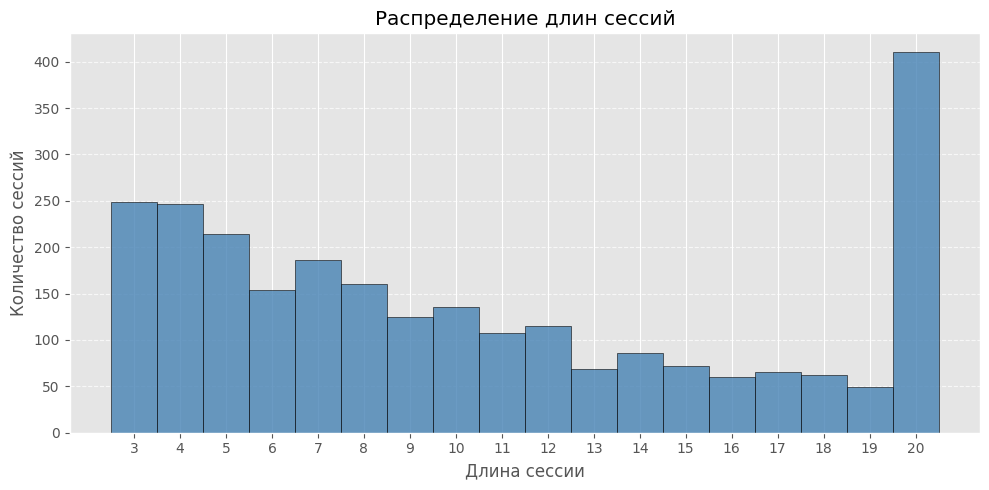

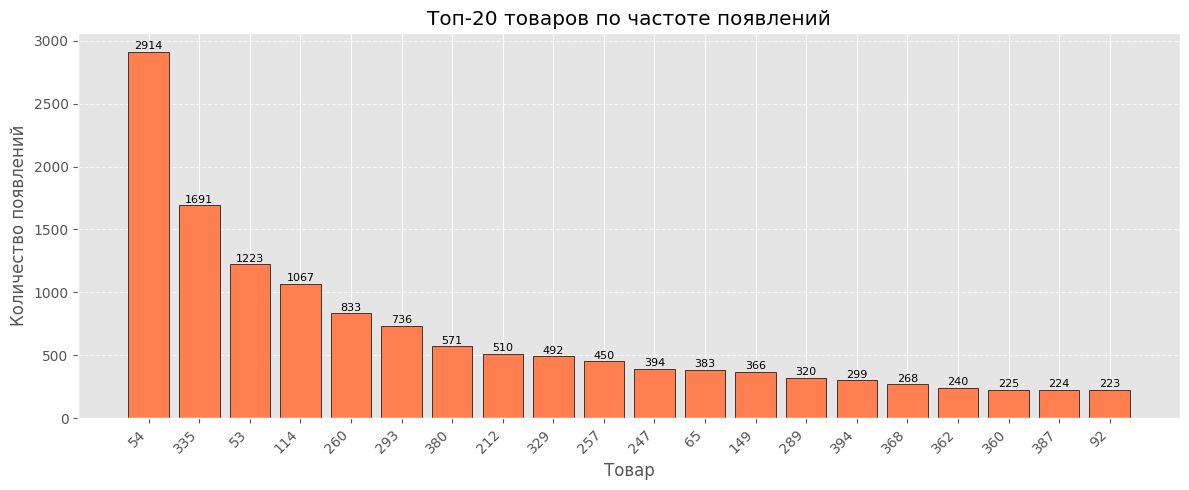

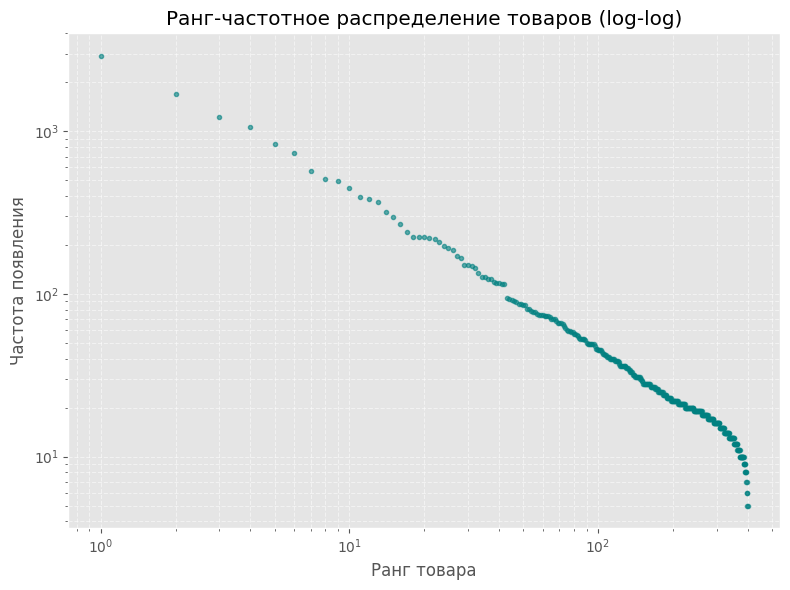

In [5]:
import ast
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

print(f"Число сессий: {len(sessions)}")
all_items = [item for s in sessions for item in s]
unique_items = set(all_items)
print(f"Число уникальных товаров: {len(unique_items)}")

lengths = [len(s) for s in sessions]
print("\nРаспределение длин сессий")
print(f"Минимальная длина: {min(lengths)}")
print(f"Максимальная длина: {max(lengths)}")
print(f"Средняя длина: {np.mean(lengths):.2f}")
print(f"Медианная длина: {np.median(lengths):.1f}")
print(f"Дисперсия длины: {np.var(lengths):.2f}")
print(f"Стандартное отклонение: {np.std(lengths):.2f}")

item_counts = Counter(all_items)
top_n = 20
top_items = item_counts.most_common(top_n)
print(f"\nТоп-{top_n} популярных товаров")
for item, cnt in top_items:
    print(f"  Товар {item}: {cnt} появлений")

pairs = set()
for s in sessions:
    for i in range(len(s)-1):
        pairs.add((s[i], s[i+1]))
print(f"\nЧисло уникальных пар: {len(pairs)}")

triplets = set()
for s in sessions:
    for i in range(len(s)-2):
        triplets.add((s[i], s[i+1], s[i+2]))
print(f"Число уникальных троек: {len(triplets)}")

total_transitions = sum(len(s)-1 for s in sessions)
print(f"Общее количество переходов: {total_transitions}")
print(f"Средняя поддержка пары: {total_transitions / len(pairs):.2f}")

plt.style.use('ggplot')

plt.figure(figsize=(10, 5))
plt.hist(lengths, bins=range(min(lengths), max(lengths)+2), align='left',
         color='steelblue', edgecolor='black', alpha=0.8)
plt.title('Распределение длин сессий')
plt.xlabel('Длина сессии')
plt.ylabel('Количество сессий')
plt.xticks(range(min(lengths), max(lengths)+1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

top_items, top_counts = zip(*top_items)
plt.figure(figsize=(12, 5))
bars = plt.bar(range(top_n), top_counts, color='coral', edgecolor='black')
plt.title(f'Топ-{top_n} товаров по частоте появлений')
plt.xlabel('Товар')
plt.ylabel('Количество появлений')
plt.xticks(range(top_n), top_items, rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
for bar, count in zip(bars, top_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(count),
             ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

freqs = sorted(item_counts.values(), reverse=True)
ranks = range(1, len(freqs)+1)
plt.figure(figsize=(8, 6))
plt.loglog(ranks, freqs, marker='.', linestyle='none', color='teal', alpha=0.6)
plt.title('Ранг-частотное распределение товаров (log-log)')
plt.xlabel('Ранг товара')
plt.ylabel('Частота появления')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#Базовое решение

In [6]:
from collections import defaultdict

def build_transition_graph(train_sessions):
    transitions = defaultdict(Counter)

    for session in train_sessions:
        for i in range(len(session) - 1):
            curr_item = session[i]
            next_item = session[i + 1]
            transitions[curr_item][next_item] += 1

    transition_probs = {}

    for item, next_items in transitions.items():
        total = sum(next_items.values())
        probs = {j: count / total for j, count in next_items.items()}
        transition_probs[item] = probs

    return transition_probs

In [7]:
def get_top_k_recommendations(
    train_sessions,
    transition_probs,
    item_counts,
    k=10
):
    popular_items = [item for item, _ in item_counts.most_common(k)]

    recommendations = []

    for session in train_sessions:
        last_item = session[-1]

        if last_item in transition_probs:
            next_items = transition_probs[last_item]

            ranked = sorted(next_items.items(), key=lambda x: x[1], reverse=True)
            recs = [item for item, _ in ranked]

        else:
            recs = []

        recs = recs[:k]

        if len(recs) < k:
            for p in popular_items:
                if p not in recs:
                    recs.append(p)
                if len(recs) == k:
                    break

        recommendations.append(recs)

    return recommendations

In [8]:
def popularity_baseline(train_sessions, item_counts, k=10):
    popular_items = [item for item, _ in item_counts.most_common(k)]
    return [popular_items for _ in train_sessions]

In [9]:
train_sessions, test_targets = train_test_split(sessions)

transition_probs = build_transition_graph(train_sessions)

model_recs = get_top_k_recommendations(
    train_sessions,
    transition_probs,
    item_counts
)

baseline_recs = popularity_baseline(train_sessions, item_counts)

model_hit = hit_at_k(model_recs, test_targets)
baseline_hit = hit_at_k(baseline_recs, test_targets)

print(f"Model Hit@10: {model_hit:.2f}")
print(f"Baseline Hit@10: {baseline_hit:.2f}")

Model Hit@10: 0.51
Baseline Hit@10: 0.38


#Модель с подбором k и порогом

In [10]:
class NgramModelWithThreshold:
    def __init__(self, k=2, min_count=5):
        self.k = k
        self.min_count = min_count
        self.transitions = defaultdict(Counter)
        self.context_counts = Counter()
        self.item_counts = Counter()

    def fit(self, sessions):
        for s in sessions:
            for i in range(len(s)-1):
                for order in range(1, self.k+1):
                    if i >= order-1:
                        ctx = tuple(s[i-order+1:i+1])
                        nxt = s[i+1]
                        self.transitions[ctx][nxt] += 1
                        self.context_counts[ctx] += 1
            for item in s:
                self.item_counts[item] += 1

    def get_candidates(self, context_tuple, top_n=10, exclude=None):
        ctx = list(context_tuple)
        while len(ctx) >= 0:
            if len(ctx) == 0:
                total = sum(self.item_counts.values())
                probs = [(item, cnt/total) for item, cnt in self.item_counts.items()]
                break
            ctx_key = tuple(ctx)
            cnt_ctx = self.context_counts.get(ctx_key, 0)
            if cnt_ctx >= self.min_count and ctx_key in self.transitions:
                total = cnt_ctx
                probs = [(item, cnt/total) for item, cnt in self.transitions[ctx_key].items()]
                break
            ctx = ctx[1:]
        if exclude:
            probs = [(it, p) for it, p in probs if it not in exclude]
        probs.sort(key=lambda x: x[1], reverse=True)
        return [it for it, _ in probs[:top_n]]

##Валидация

In [11]:
from sklearn.model_selection import train_test_split as sklearn_split

train_sessions_part, val_sessions = sklearn_split(train_sessions, test_size=0.2, random_state=42)
val_targets = [s[-1] for s in val_sessions]
val_histories = [s[:-1] for s in val_sessions]

In [12]:
best_hit = 0
best_params = (1, 1)
results = []

for k in range(1, 21):
    for mc in [0,1,2,5,10]:
        model = NgramModelWithThreshold(k=k, min_count=mc)
        model.fit(train_sessions_part)
        recs = []
        for hist in val_histories:
            ctx_len = min(len(hist), k)
            ctx = tuple(hist[-ctx_len:]) if ctx_len > 0 else tuple()
            recs.append(model.get_candidates(ctx, top_n=10, exclude={hist[-1]} if hist else set()))
        hit = hit_at_k(recs, val_targets)
        results.append((k, mc, hit))
        if hit > best_hit:
            best_hit = hit
            best_params = (k, mc)
        print(f"k={k}, min_count={mc}: Hit@10 = {hit:.2f}")

print(f"\nЛучшие параметры: k={best_params[0]}, min_count={best_params[1]} (Hit@10={best_hit:.2f})")

k=1, min_count=0: Hit@10 = 0.49
k=1, min_count=1: Hit@10 = 0.49
k=1, min_count=2: Hit@10 = 0.49
k=1, min_count=5: Hit@10 = 0.49
k=1, min_count=10: Hit@10 = 0.49
k=2, min_count=0: Hit@10 = 0.35
k=2, min_count=1: Hit@10 = 0.35
k=2, min_count=2: Hit@10 = 0.38
k=2, min_count=5: Hit@10 = 0.43
k=2, min_count=10: Hit@10 = 0.46
k=3, min_count=0: Hit@10 = 0.32
k=3, min_count=1: Hit@10 = 0.32
k=3, min_count=2: Hit@10 = 0.35
k=3, min_count=5: Hit@10 = 0.42
k=3, min_count=10: Hit@10 = 0.45
k=4, min_count=0: Hit@10 = 0.32
k=4, min_count=1: Hit@10 = 0.32
k=4, min_count=2: Hit@10 = 0.35
k=4, min_count=5: Hit@10 = 0.42
k=4, min_count=10: Hit@10 = 0.45
k=5, min_count=0: Hit@10 = 0.31
k=5, min_count=1: Hit@10 = 0.31
k=5, min_count=2: Hit@10 = 0.35
k=5, min_count=5: Hit@10 = 0.42
k=5, min_count=10: Hit@10 = 0.45
k=6, min_count=0: Hit@10 = 0.31
k=6, min_count=1: Hit@10 = 0.31
k=6, min_count=2: Hit@10 = 0.35
k=6, min_count=5: Hit@10 = 0.42
k=6, min_count=10: Hit@10 = 0.45
k=7, min_count=0: Hit@10 = 0.31
k=

##Кросс-валидация

In [13]:
from sklearn.model_selection import KFold
import numpy as np

def cross_val_score(sessions, k_order, min_count, n_folds=5, random_state=42):

    kf = KFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    hits = []

    for train_idx, val_idx in kf.split(sessions):
        train_sess = [sessions[i] for i in train_idx]
        val_sess = [sessions[i] for i in val_idx]

        model = NgramModelWithThreshold(k=k_order, min_count=min_count)
        model.fit(train_sess)

        val_histories = [s[:-1] for s in val_sess]
        val_targets = [s[-1] for s in val_sess]

        recs = []
        for hist in val_histories:
            ctx_len = min(len(hist), k_order)
            ctx = tuple(hist[-ctx_len:]) if ctx_len > 0 else tuple()
            recs.append(model.get_candidates(ctx, top_n=10, exclude={hist[-1]} if hist else set()))
        hit = hit_at_k(recs, val_targets)
        hits.append(hit)

    return hits

In [14]:
import itertools

all_sessions = sessions

k_values = [1, 2, 3, 5, 10]
min_counts = [0, 1, 2, 5, 10, 20]
n_folds = 5

results_cv = []

for k, mc in itertools.product(k_values, min_counts):
    fold_scores = cross_val_score(all_sessions, k, mc, n_folds=n_folds)
    mean_hit = np.mean(fold_scores)
    std_hit = np.std(fold_scores)
    results_cv.append((k, mc, mean_hit, std_hit))
    print(f"k={k:2d}, min_count={mc:2d}: Hit@10 = {mean_hit:.4f} ± {std_hit:.4f}")

best_cv = max(results_cv, key=lambda x: x[2])
print(f"\nЛучшие параметры: k={best_cv[0]}, min_count={best_cv[1]}, "
      f"Hit@10 = {best_cv[2]:.2f} ± {best_cv[3]:.2f}")

k= 1, min_count= 0: Hit@10 = 0.5057 ± 0.0208
k= 1, min_count= 1: Hit@10 = 0.5057 ± 0.0208
k= 1, min_count= 2: Hit@10 = 0.5057 ± 0.0208
k= 1, min_count= 5: Hit@10 = 0.5064 ± 0.0200
k= 1, min_count=10: Hit@10 = 0.5084 ± 0.0215
k= 1, min_count=20: Hit@10 = 0.5064 ± 0.0182
k= 2, min_count= 0: Hit@10 = 0.3423 ± 0.0111
k= 2, min_count= 1: Hit@10 = 0.3423 ± 0.0111
k= 2, min_count= 2: Hit@10 = 0.3856 ± 0.0179
k= 2, min_count= 5: Hit@10 = 0.4441 ± 0.0214
k= 2, min_count=10: Hit@10 = 0.4721 ± 0.0254
k= 2, min_count=20: Hit@10 = 0.4838 ± 0.0223
k= 3, min_count= 0: Hit@10 = 0.3002 ± 0.0147
k= 3, min_count= 1: Hit@10 = 0.3002 ± 0.0147
k= 3, min_count= 2: Hit@10 = 0.3645 ± 0.0169
k= 3, min_count= 5: Hit@10 = 0.4359 ± 0.0172
k= 3, min_count=10: Hit@10 = 0.4682 ± 0.0223
k= 3, min_count=20: Hit@10 = 0.4827 ± 0.0213
k= 5, min_count= 0: Hit@10 = 0.2975 ± 0.0150
k= 5, min_count= 1: Hit@10 = 0.2975 ± 0.0150
k= 5, min_count= 2: Hit@10 = 0.3641 ± 0.0172
k= 5, min_count= 5: Hit@10 = 0.4359 ± 0.0172
k= 5, min_

In [15]:
final_model = NgramModelWithThreshold(k=1, min_count=10)
final_model.fit(train_sessions)
final_recs = []
for hist in train_sessions:
    ctx_len = min(len(hist), 2)
    ctx = tuple(hist[-ctx_len:]) if ctx_len > 0 else tuple()
    final_recs.append(final_model.get_candidates(ctx, top_n=10, exclude={hist[-1]} if hist else set()))

test_hit = hit_at_k(final_recs, test_targets)
print(f"Финальный Hit@10 {test_hit:.2f}")

Финальный Hit@10 0.51


#Модель с выбором k, порогом и сглаживанием

In [16]:
class NgramModelWithThreshold:
    def __init__(self, k=1, min_count=5, alpha=1.0):
        self.k = k
        self.min_count = min_count
        self.alpha = alpha
        self.transitions = defaultdict(Counter)
        self.context_counts = Counter()
        self.item_counts = Counter()

    def fit(self, sessions):
        for s in sessions:
            for i in range(len(s) - 1):
                for order in range(1, self.k + 1):
                    if i >= order - 1:
                        ctx = tuple(s[i - order + 1 : i + 1])
                        nxt = s[i + 1]
                        self.transitions[ctx][nxt] += 1
                        self.context_counts[ctx] += 1
            for item in s:
                self.item_counts[item] += 1

    def get_candidates(self, context_tuple, top_n=10, exclude=None):
        ctx = list(context_tuple)
        total_all = sum(self.item_counts.values())
        prior_prob = {item: cnt / total_all for item, cnt in self.item_counts.items()}

        while len(ctx) >= 0:
            if len(ctx) == 0:
                total = total_all
                probs = [(item, cnt / total) for item, cnt in self.item_counts.items()]
                break
            ctx_key = tuple(ctx)
            cnt_ctx = self.context_counts.get(ctx_key, 0)
            if cnt_ctx >= self.min_count and ctx_key in self.transitions:
                total = cnt_ctx
                smoothed_probs = {}
                all_items = set(self.transitions[ctx_key].keys()) | set(self.item_counts.keys())
                for item in all_items:
                    empirical_count = self.transitions[ctx_key].get(item, 0)
                    smoothed = (empirical_count + self.alpha * prior_prob.get(item, 0)) / (total + self.alpha)
                    smoothed_probs[item] = smoothed
                probs = [(item, prob) for item, prob in smoothed_probs.items()]
                break
            ctx = ctx[1:]

        if exclude:
            probs = [(it, p) for it, p in probs if it not in exclude]
        probs.sort(key=lambda x: x[1], reverse=True)
        return [it for it, _ in probs[:top_n]]

In [17]:
final_model = NgramModelWithThreshold(k=1, min_count=10, alpha=10)
final_model.fit(train_sessions)
final_recs = []
for hist in train_sessions:
    ctx_len = min(len(hist), 2)
    ctx = tuple(hist[-ctx_len:]) if ctx_len > 0 else tuple()
    final_recs.append(final_model.get_candidates(ctx, top_n=10, exclude={hist[-1]} if hist else set()))

test_hit = hit_at_k(final_recs, test_targets)
print(f"Финальный Hit@10 {test_hit:.2f}")

Финальный Hit@10 0.53
